In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("laptopPrice.csv")

In [3]:
df.sample(10)

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
707,acer,AMD,Ryzen 5,Not Available,4 GB,DDR4,512 GB,0 GB,Windows,64-bit,0 GB,Casual,1 year,No,No,44990,4 stars,313,39
313,Lenovo,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,64-bit,0 GB,ThinNlight,3 years,No,No,147000,3 stars,0,0
67,Lenovo,Intel,Core i3,10th,4 GB,DDR4,256 GB,0 GB,Windows,64-bit,0 GB,Casual,1 year,No,Yes,41998,4 stars,529,39
816,ASUS,AMD,Ryzen 9,Not Available,4 GB,DDR4,1024 GB,0 GB,Windows,32-bit,6 GB,Casual,No warranty,No,No,138990,3 stars,0,0
810,ASUS,AMD,Ryzen 9,Not Available,4 GB,DDR4,1024 GB,0 GB,Windows,64-bit,0 GB,Casual,1 year,No,No,121990,3 stars,0,0
589,MSI,Intel,Core i9,11th,16 GB,DDR4,1024 GB,0 GB,Windows,64-bit,6 GB,Casual,No warranty,No,No,192990,3 stars,0,0
252,HP,Intel,Core i5,11th,8 GB,LPDDR4X,512 GB,0 GB,Windows,64-bit,0 GB,Casual,No warranty,Yes,No,97990,5 stars,3,1
663,DELL,AMD,Ryzen 5,Not Available,8 GB,DDR4,256 GB,0 GB,Windows,64-bit,0 GB,ThinNlight,1 year,No,No,44490,4 stars,14,1
158,HP,Intel,Core i3,7th,8 GB,DDR4,0 GB,1024 GB,Windows,64-bit,2 GB,Casual,No warranty,No,No,49279,4 stars,38,3
548,HP,Intel,Core i7,11th,16 GB,DDR4,1024 GB,0 GB,Windows,64-bit,4 GB,Casual,No warranty,No,No,121990,3 stars,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

In [5]:
df.describe()

,Price,Number of Ratings,Number of Reviews
count,823.00,823.00,823.00
mean,76745.18,315.30,37.61
std,45101.79,1047.38,121.73
min,16990.00,0.00,0.00
25%,46095.00,0.00,0.00
50%,64990.00,17.00,2.00
75%,89636.00,139.50,18.00
max,441990.00,15279.00,1947.00


In [6]:
df.isnull().sum()

brand                0
processor_brand      0
processor_name       0
processor_gnrtn      0
ram_gb               0
ram_type             0
ssd                  0
hdd                  0
os                   0
os_bit               0
graphic_card_gb      0
weight               0
warranty             0
Touchscreen          0
msoffice             0
Price                0
rating               0
Number of Ratings    0
Number of Reviews    0
dtype: int64

In [7]:
df["ssd"] = (
    df["ssd"]
    .astype(str)
    .str.replace("GB", "", regex=False)
    .str.replace("TB", "000", regex=False)  # converts 1 TB -> 1000
    .str.strip()
)
df["hdd"] = (
    df["hdd"]
    .astype(str)
    .str.replace("GB", "", regex=False)
    .str.replace("TB", "000", regex=False)  # converts 1 TB -> 1000
    .str.strip()
)
df["graphic_card_gb"] = (
    df["graphic_card_gb"]
    .astype(str)
    .str.replace("GB", "", regex=False)
    .str.replace("TB", "000", regex=False)  # converts 1 TB -> 1000
    .str.strip()
)
df["ram_gb"] = (
    df["ram_gb"]
    .astype(str)
    .str.replace("GB", "", regex=False)
    .str.strip()
)
df["ssd"] = pd.to_numeric(df["ssd"], errors="coerce").fillna(0)

df["graphic_card_gb"] = pd.to_numeric(df["graphic_card_gb"], errors="coerce").fillna(0)
df["hdd"] = pd.to_numeric(df["hdd"], errors="coerce").fillna(0)
df["ram_gb"] = pd.to_numeric(df["ram_gb"], errors="coerce").fillna(0)
df["has_ssd"] = (df["ssd"] > 0).astype(int)
df["has_dedicated_gpu"] = (df["graphic_card_gb"] > 0).astype(int)
df["storage_ratio"] = df["ssd"] / (df["hdd"] + 1)

In [8]:
df.shape

(823, 22)

In [9]:
df=df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print(df["hdd"].value_counts())

hdd
0       602
1024    159
512      40
2048      1
Name: count, dtype: int64


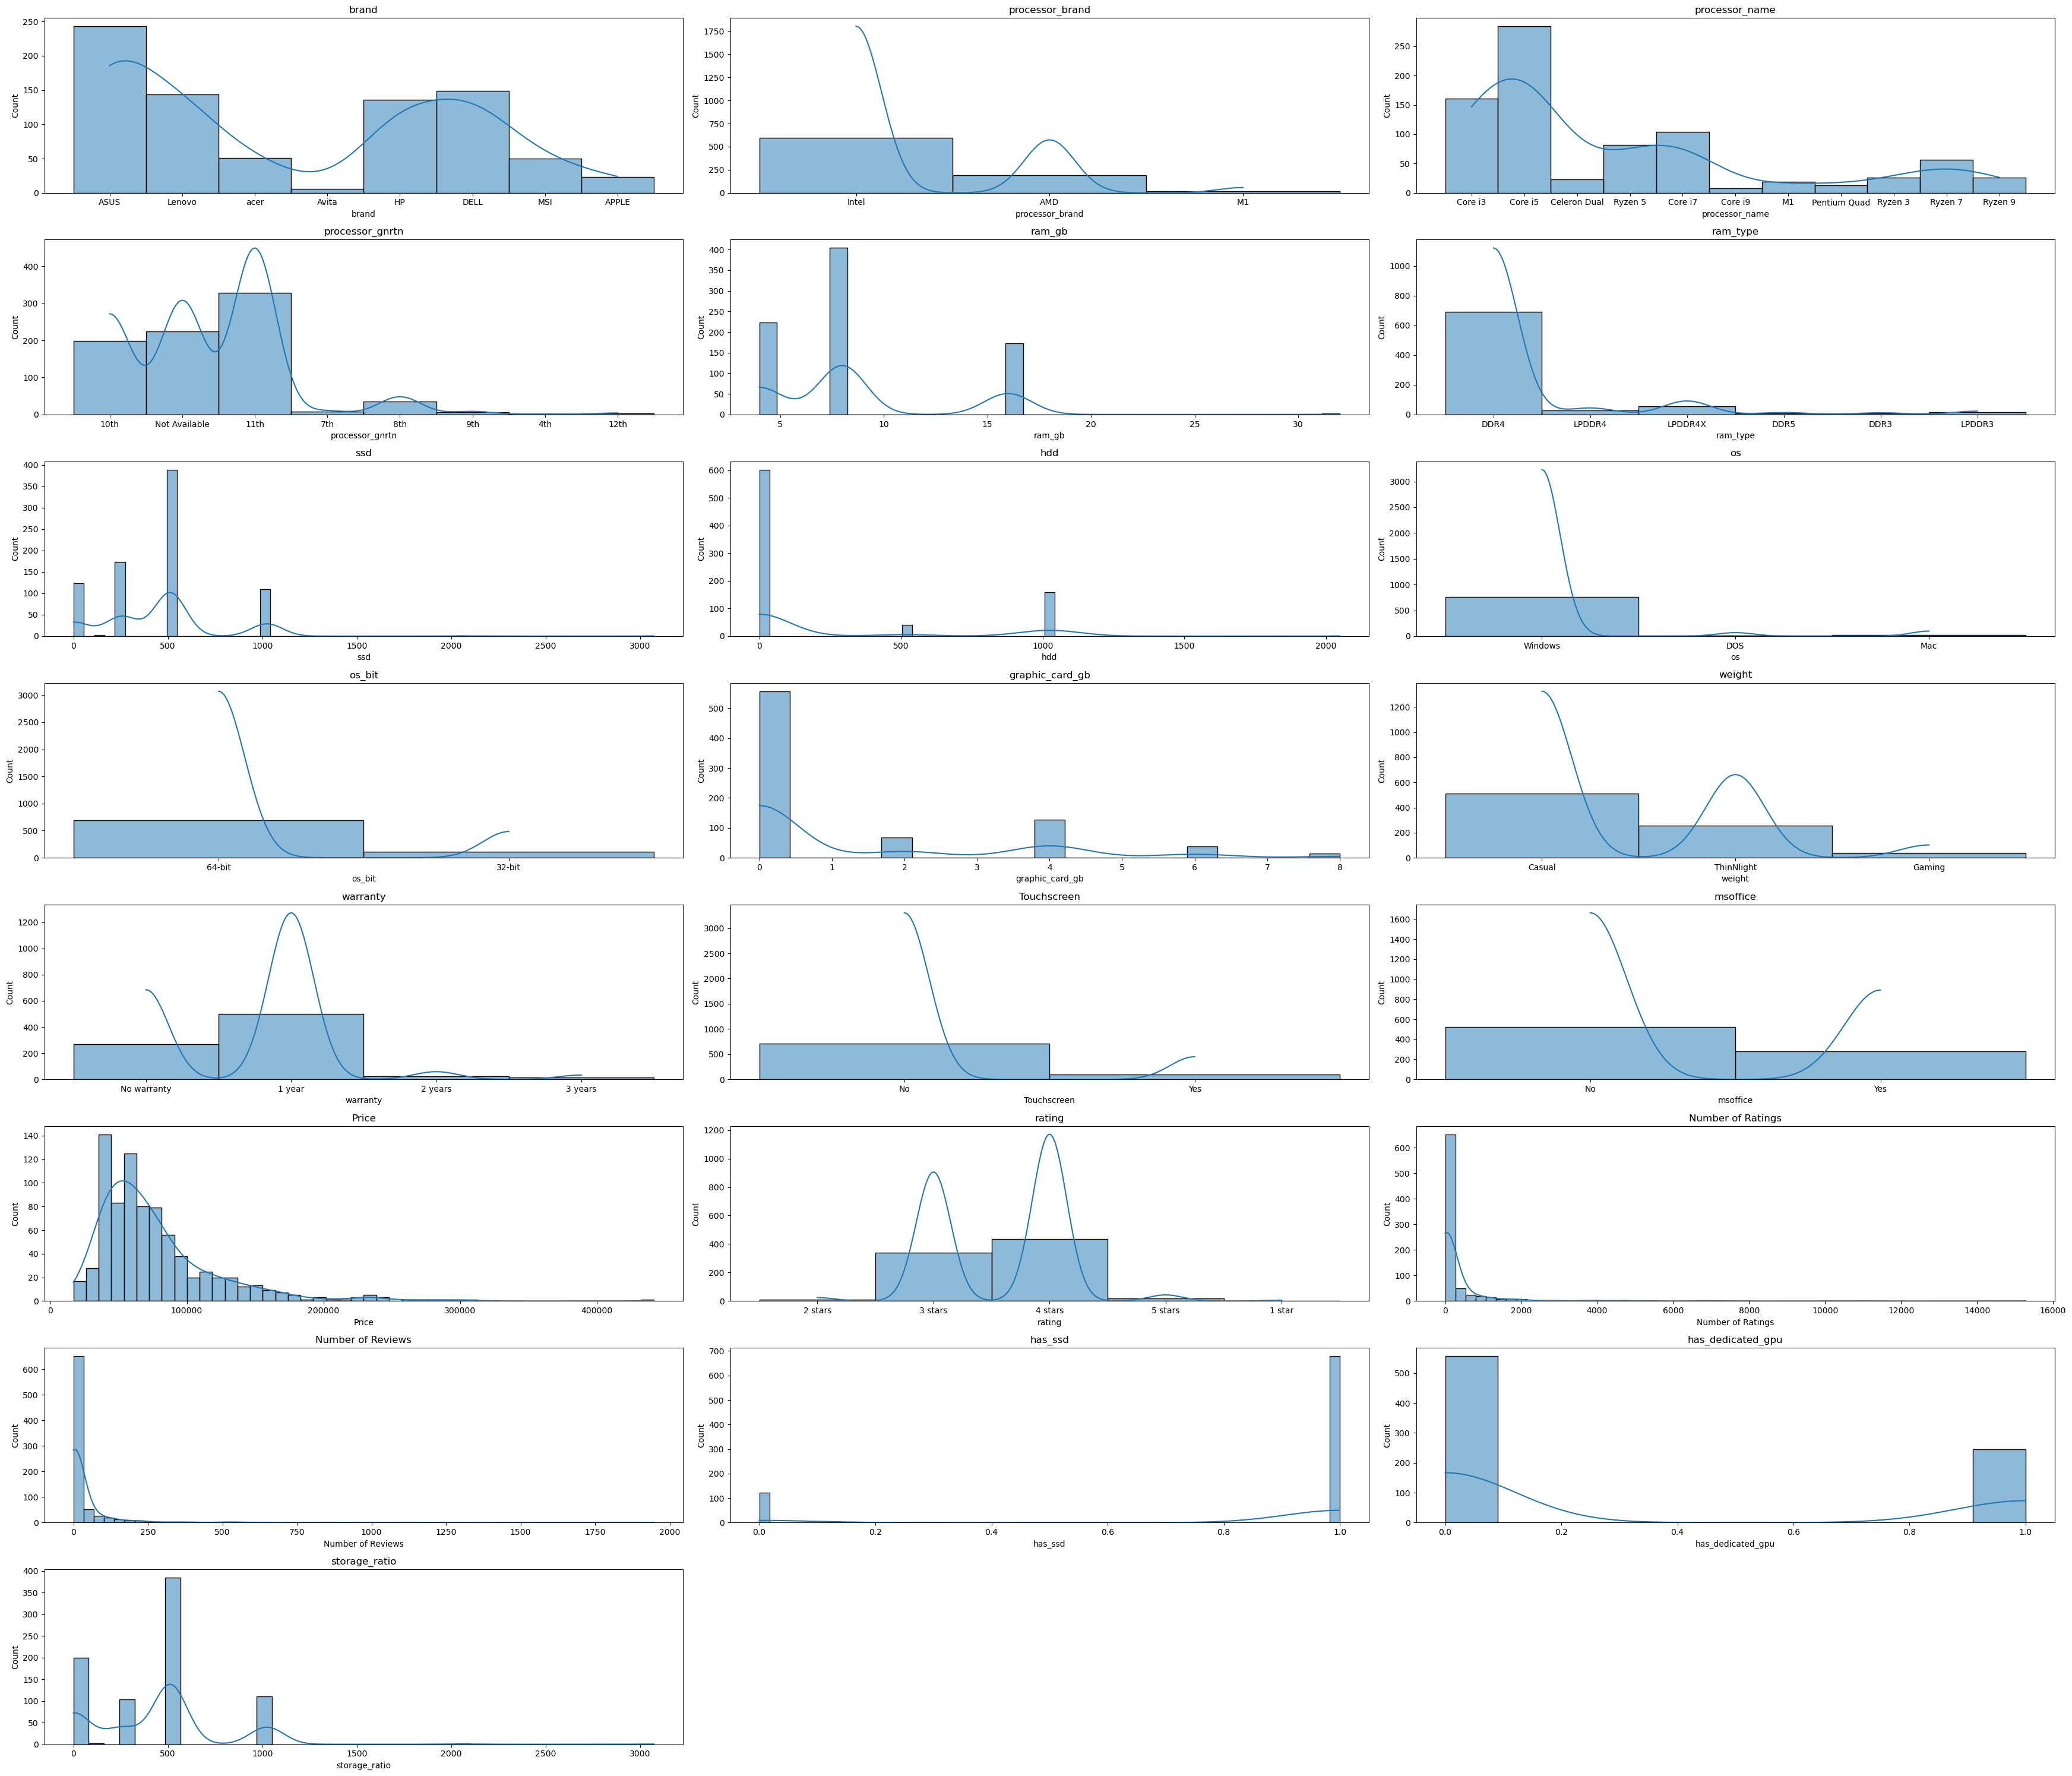

In [12]:
num_cols = df.columns

plt.figure(figsize=(35,30))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)
    sns.histplot(x=df[col],kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

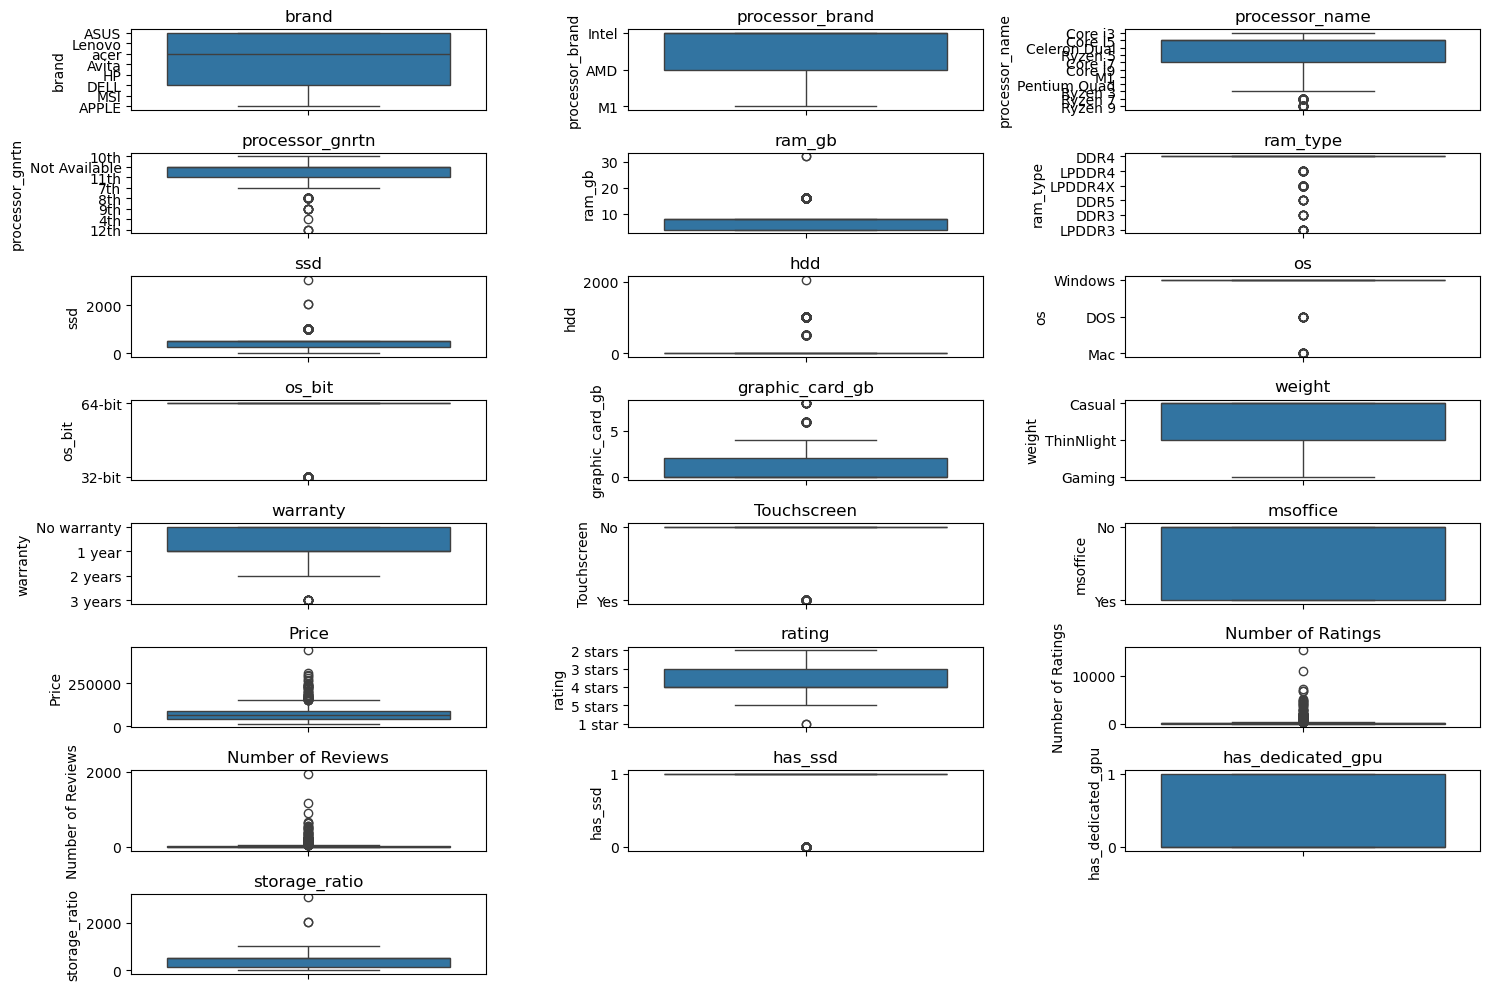

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


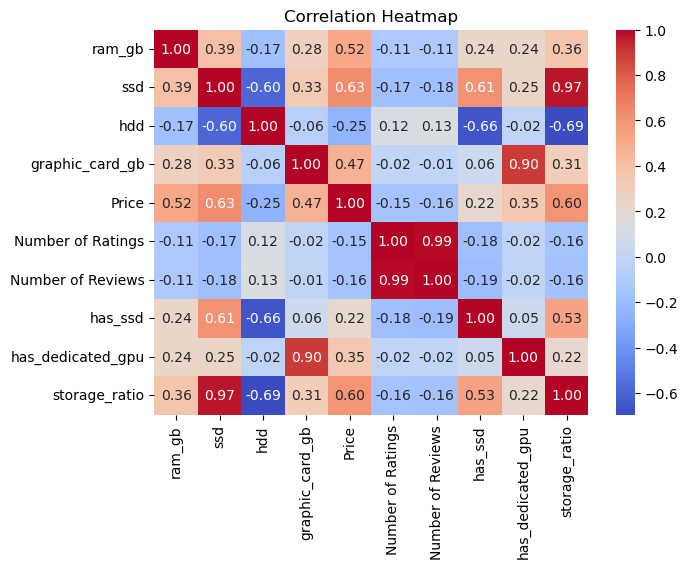

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

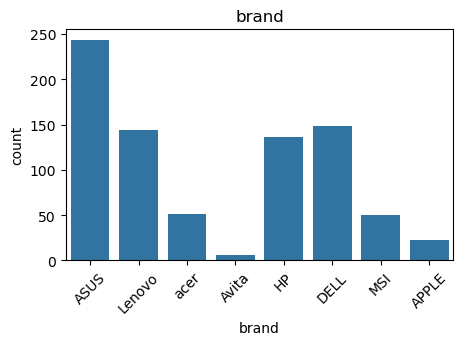

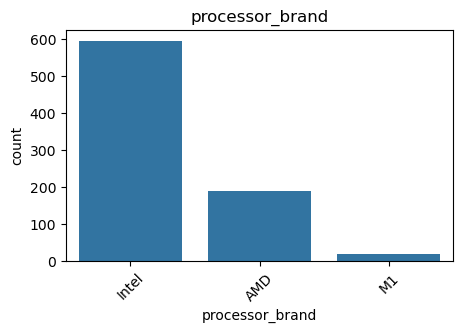

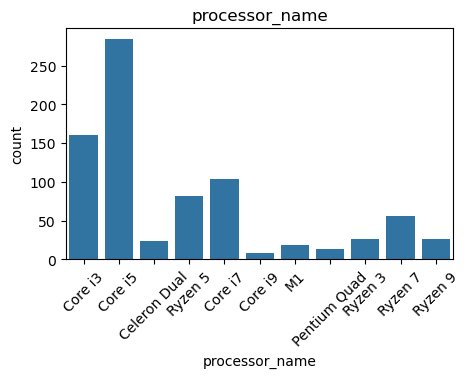

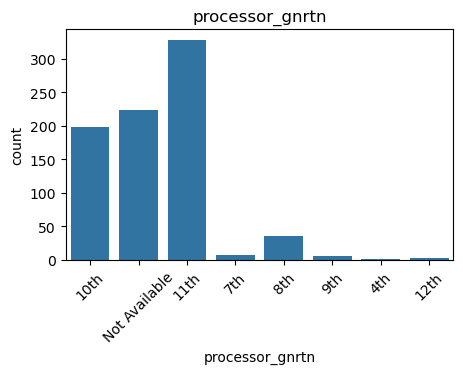

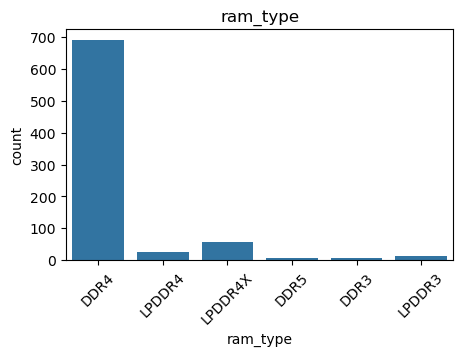

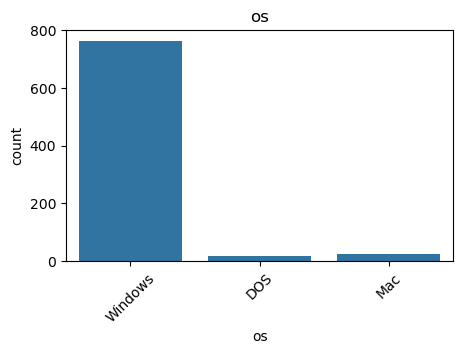

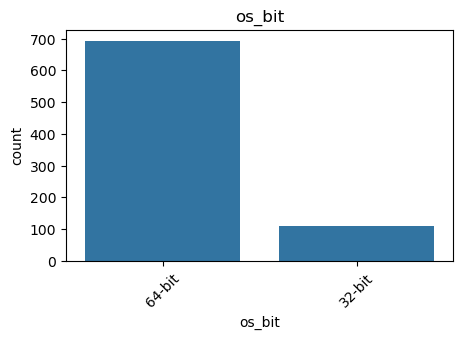

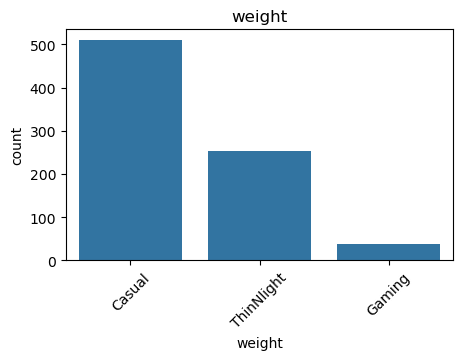

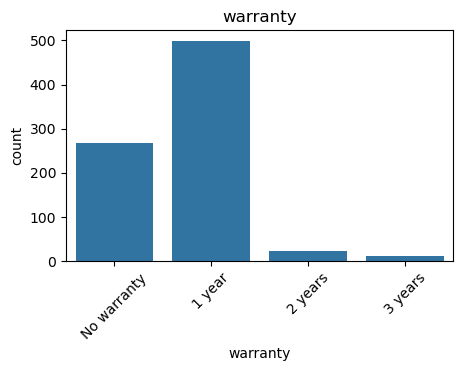

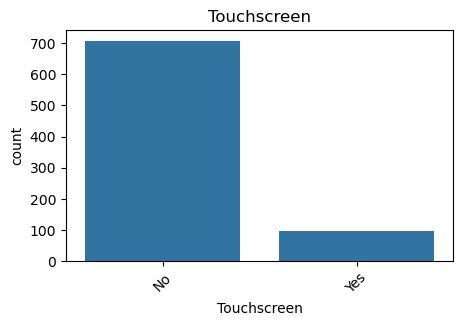

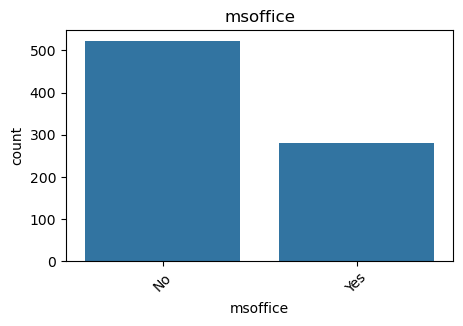

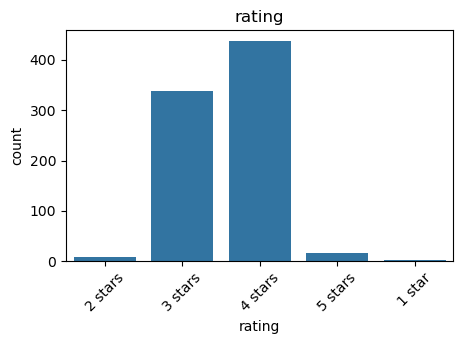

In [15]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

In [16]:
df["processor_gnrtn"] = df["processor_gnrtn"].replace("Not Available", np.nan,)


In [17]:
df["processor_gnrtn"].value_counts()

processor_gnrtn
11th    328
10th    198
8th      35
7th       7
9th       6
12th      3
4th       1
Name: count, dtype: int64

In [18]:
df.isnull().sum()



brand                  0
processor_brand        0
processor_name         0
processor_gnrtn      224
ram_gb                 0
ram_type               0
ssd                    0
hdd                    0
os                     0
os_bit                 0
graphic_card_gb        0
weight                 0
warranty               0
Touchscreen            0
msoffice               0
Price                  0
rating                 0
Number of Ratings      0
Number of Reviews      0
has_ssd                0
has_dedicated_gpu      0
storage_ratio          0
dtype: int64

In [19]:
df.sample(5)

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,...,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews,has_ssd,has_dedicated_gpu,storage_ratio
626,HP,Intel,Pentium Quad,NaN,8,DDR4,256,0,Windows,64-bit,...,1 year,No,Yes,32990,4 stars,77,9,1,0,256.00
114,HP,Intel,Core i3,11th,4,DDR4,512,0,Windows,64-bit,...,1 year,No,Yes,45490,4 stars,523,66,1,0,512.00
512,HP,Intel,Core i7,11th,16,DDR4,512,0,Windows,64-bit,...,1 year,No,Yes,92000,4 stars,8,1,1,1,512.00
191,HP,Intel,Celeron Dual,NaN,4,DDR4,0,512,Windows,64-bit,...,No warranty,No,No,27990,3 stars,596,65,0,0,0.00
6,ASUS,Intel,Celeron Dual,NaN,4,DDR4,0,512,Windows,32-bit,...,No warranty,No,No,21990,3 stars,31,3,0,0,0.00


In [20]:
df["os_bit"].unique()

array(['64-bit', '32-bit'], dtype=object)

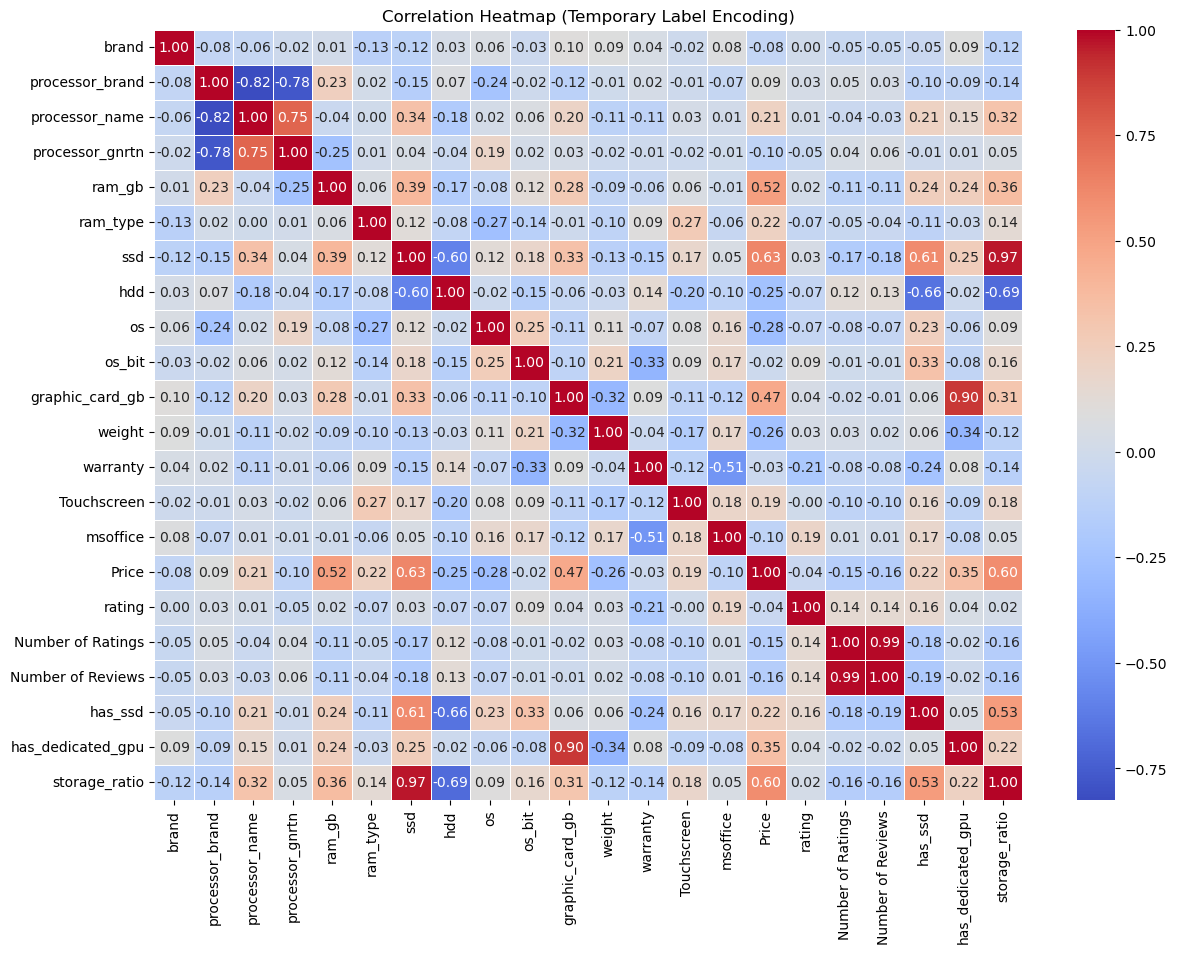

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Create a copy of the original dataset
df_temp = df.copy()      # Replace 'df' with your DataFrame name

# Label Encode all categorical columns
le = LabelEncoder()

for col in df_temp.select_dtypes(include=['object', 'category']).columns:
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

# Correlation matrix
corr_matrix = df_temp.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap (Temporary Label Encoding)")
plt.show()

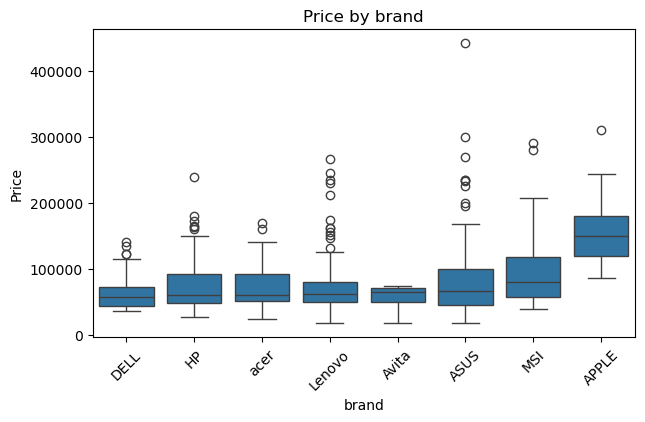

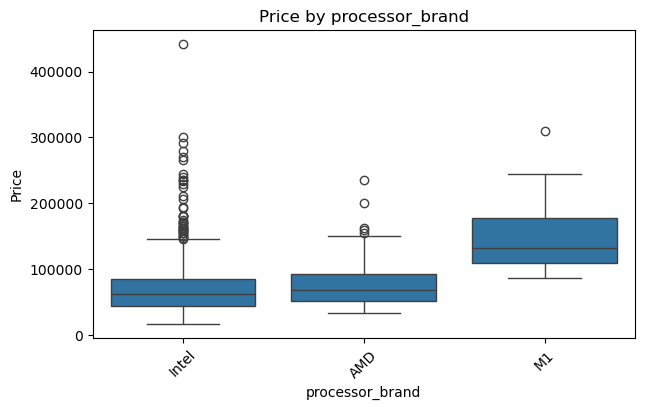

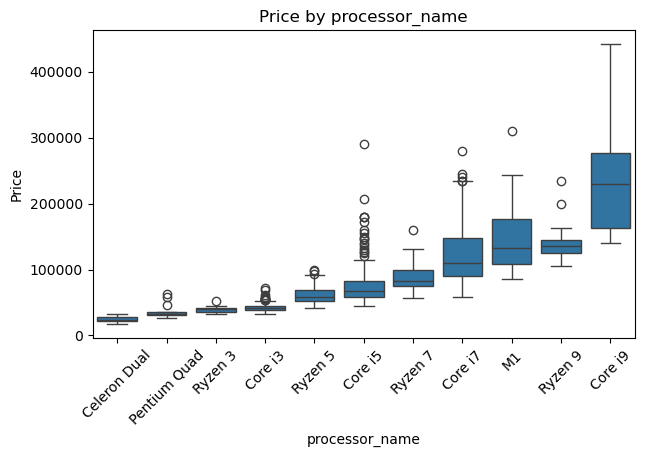

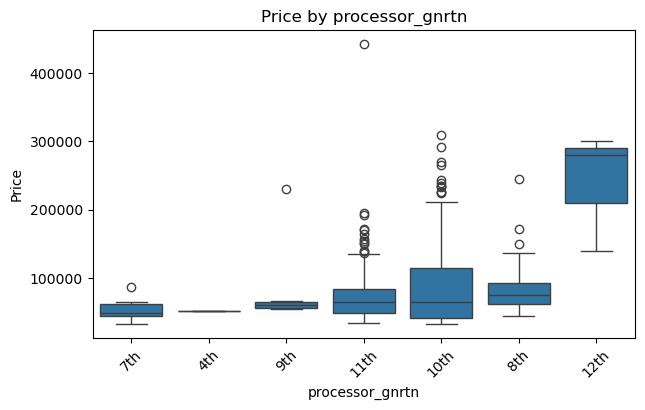

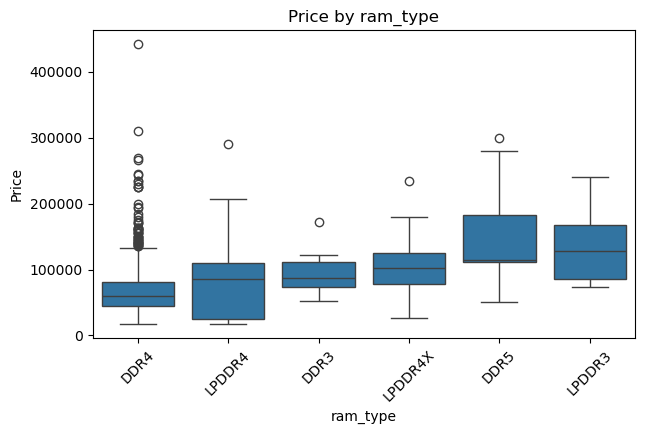

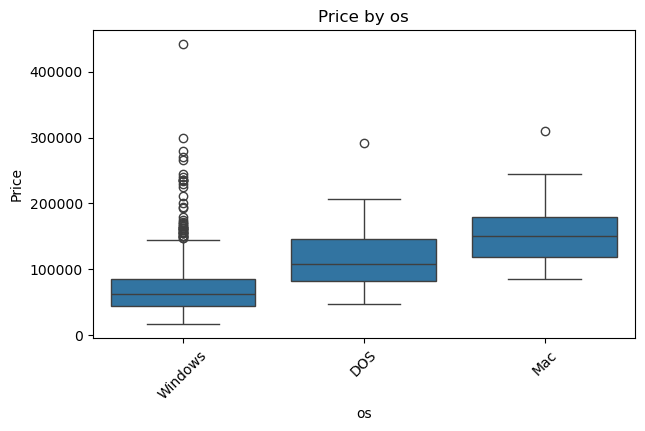

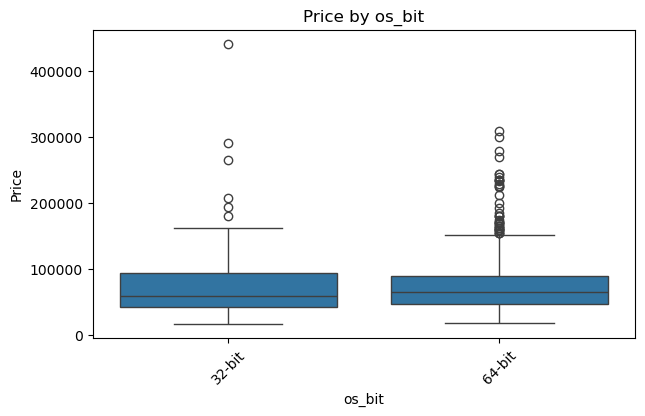

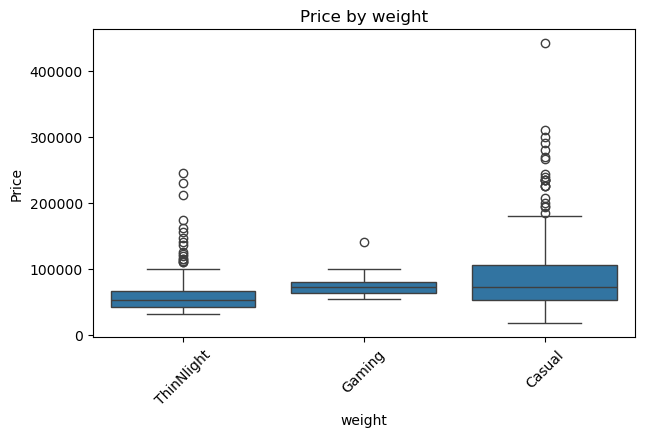

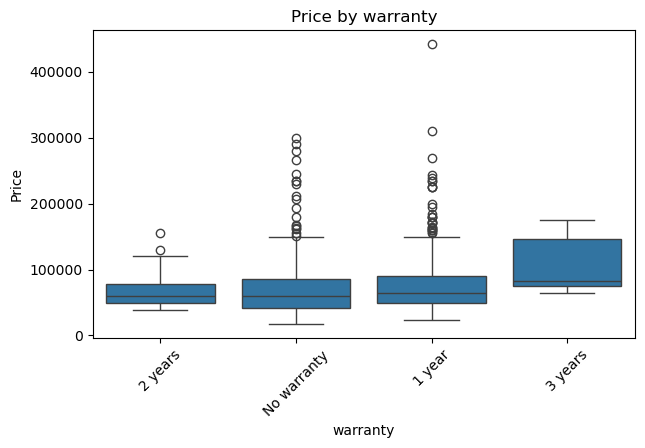

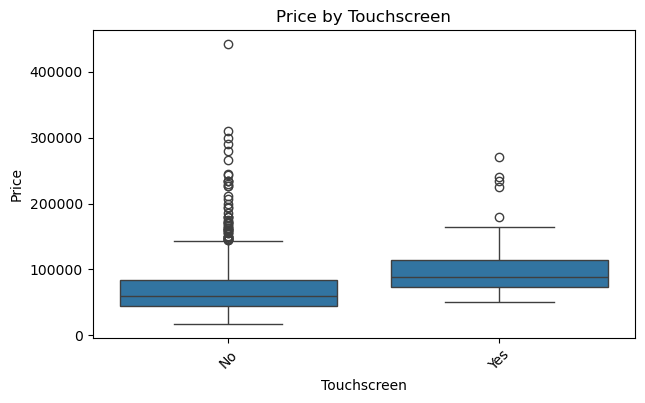

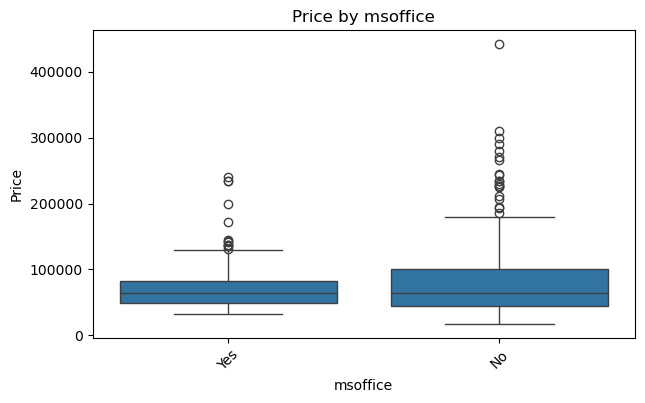

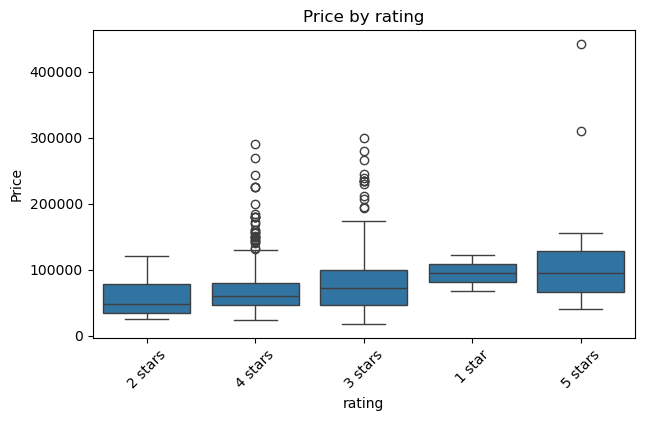

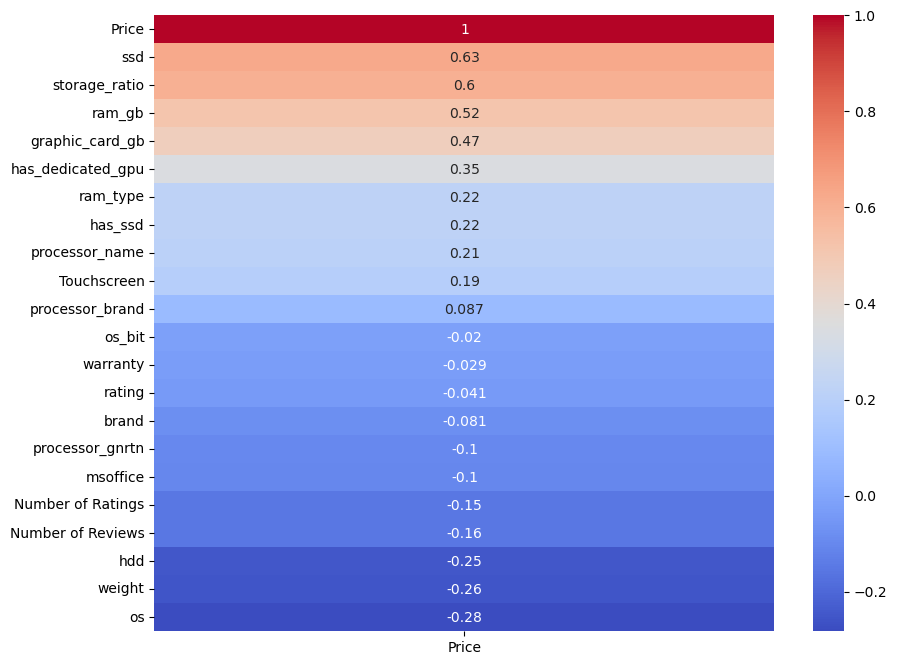

Text(0.5, 1.0, 'log1p(Price)')

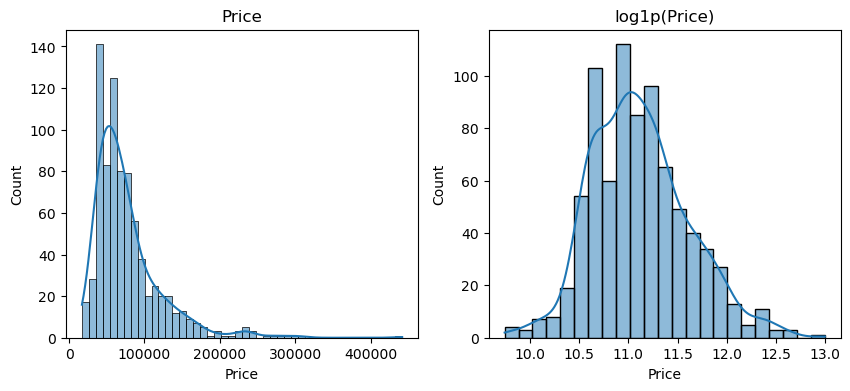

In [22]:
# Bivariate: how does each categorical actually move price?
cat_cols = df.select_dtypes(include="object").columns.drop("Price", errors="ignore")
for col in cat_cols:
    plt.figure(figsize=(7,4))
    order = df.groupby(col)["Price"].median().sort_values().index
    sns.boxplot(x=col, y="Price", data=df, order=order)
    plt.xticks(rotation=45)
    plt.title(f"Price by {col}")
    plt.show()

# Full correlation matrix on label-encoded features (your cell 16 built df_temp but never plotted it)
plt.figure(figsize=(10,8))
sns.heatmap(df_temp.corr(numeric_only=True)[["Price"]].sort_values("Price", ascending=False),
            annot=True, cmap="coolwarm")
plt.show()

# Target skew, before/after log
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.histplot(df["Price"], kde=True, ax=ax[0]).set_title("Price")
sns.histplot(np.log1p(df["Price"]), kde=True, ax=ax[1]).set_title("log1p(Price)")

In [23]:
# Features (all columns except 'price')
x = df.drop(columns=["Price"])
#
# Target (only the 'price' column)
y = df["Price"]

In [24]:
 from sklearn.model_selection import train_test_split

 xtr, xte, ytr, yte = train_test_split(
     x,
     y,
     test_size=0.2,
     random_state=42,
     
 )

In [25]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer

# Step 1: Ordinal Encode
order = [["4th", "7th", "8th", "9th", "10th", "11th", "12th"]]

encoder = OrdinalEncoder(
    categories=order,
    handle_unknown="use_encoded_value",
    unknown_value=np.nan
)

xtr["processor_gnrtn"] = encoder.fit_transform(xtr[["processor_gnrtn"]]).ravel()
xte["processor_gnrtn"] = encoder.transform(xte[["processor_gnrtn"]]).ravel()

# Step 2: KNN Imputation
knn = KNNImputer(n_neighbors=5)

xtr["processor_gnrtn"] = knn.fit_transform(xtr[["processor_gnrtn"]]).ravel()
xte["processor_gnrtn"] = knn.transform(xte[["processor_gnrtn"]]).ravel()

In [26]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = [ "warranty",
                "os_bit", "rating", "Touchscreen", "msoffice"]
# processor_gnrtn removed — already encoded + imputed earlier

ordinal_categories = [
 
    
    ["No warranty", "1 year", "2 years", "3 years"],                # warranty
    ["32-bit", "64-bit"],                                           # os_bit
    ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"],          # rating
    ["No", "Yes"],                                                  # Touchscreen
    ["No", "Yes"],                                                  # msoffice
]

ord_encoder = OrdinalEncoder(categories=ordinal_categories)

xtr[ordinal_cols] = ord_encoder.fit_transform(xtr[ordinal_cols])
xte[ordinal_cols] = ord_encoder.transform(xte[ordinal_cols])

In [27]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

nominal_cols = ["brand", "processor_brand", "processor_name", "ram_type", "os", "weight"]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

ohe.fit(xtr[nominal_cols])

X_train_ohe = pd.DataFrame(
    ohe.transform(xtr[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=xtr.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(xte[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=xte.index
)

xtr = pd.concat([xtr.drop(columns=nominal_cols), X_train_ohe], axis=1)
xte = pd.concat([xte.drop(columns=nominal_cols), X_test_ohe], axis=1)

In [42]:
from sklearn.preprocessing import PowerTransformer

# Get all numerical feature columns
feature_num_cols = xtr.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

# Only flag columns that are actually continuous (more than 2 unique values)
# — this excludes one-hot dummy columns like brand_APPLE, os_DOS, etc.
skewed_cols = [
    col for col in feature_num_cols
    if xtr[col].nunique() > 2 and abs(xtr[col].skew()) > 1
]

print("Skewed columns:", skewed_cols)

pt = PowerTransformer(method="yeo-johnson")

xtr[skewed_cols] = pt.fit_transform(xtr[skewed_cols])
xte[skewed_cols] = pt.transform(xte[skewed_cols])

Skewed columns: ['hdd']


In [43]:
import numpy as np

ytr = np.log1p(ytr)
yte = np.log1p(yte)

In [44]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)

   
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')

    print(f"Cross Val R² Score : {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"Test R² Score      : {r2:.4f}")
    print(f"MSE                : {mse:.4f}")
    print(f"MAE                : {mae:.4f}")
    print(f"RMSE               : {rmse:.4f}")

In [45]:
xtr

,processor_gnrtn,ram_gb,ssd,hdd,os_bit,graphic_card_gb,warranty,Touchscreen,msoffice,rating,...,ram_type_DDR5,ram_type_LPDDR3,ram_type_LPDDR4,ram_type_LPDDR4X,os_DOS,os_Mac,os_Windows,weight_Casual,weight_Gaming,weight_ThinNlight
442,0.98,8,-0.34,1.68,-2.51,-0.66,1.00,-0.37,1.00,3.00,...,-0.10,-0.14,-0.18,-0.27,-0.13,-0.17,0.21,1.00,-0.22,0.00
598,-0.89,16,-1.90,1.67,-2.51,1.63,0.00,-0.37,0.00,2.00,...,-0.10,-0.14,-0.18,3.64,7.94,-0.17,-4.68,1.00,-0.22,0.00
452,0.98,8,-0.34,1.68,0.40,1.35,1.00,-0.37,1.00,3.00,...,-0.10,-0.14,-0.18,-0.27,-0.13,-0.17,0.21,1.00,-0.22,0.00
696,-0.26,8,0.39,-0.60,0.40,-0.66,1.00,-0.37,1.00,2.00,...,-0.10,-0.14,-0.18,-0.27,-0.13,-0.17,0.21,0.00,-0.22,1.00
339,0.98,8,0.39,-0.60,0.40,-0.66,1.00,2.69,0.00,3.00,...,-0.10,-0.14,-0.18,3.64,-0.13,-0.17,0.21,1.00,-0.22,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,-0.89,4,-0.34,-0.60,-2.51,-0.66,0.00,-0.37,0.00,2.00,...,-0.10,-0.14,-0.18,-0.27,-0.13,-0.17,0.21,1.00,-0.22,0.00
108,0.98,8,0.39,-0.60,0.40,-0.66,1.00,2.69,0.00,3.00,...,-0.10,-0.14,-0.18,-0.27,-0.13,-0.17,0.21,1.00,-0.22,0.00
275,-0.89,8,0.39,-0.60,0.40,1.35,1.00,-0.37,1.00,2.00,...,-0.10,-0.14,-0.18,-0.27,-0.13,-0.17,0.21,1.00,-0.22,0.00
445,0.98,8,-0.34,1.68,0.40,-0.66,1.00,-0.37,0.00,2.00,...,-0.10,-0.14,-0.18,-0.27,-0.13,-0.17,0.21,1.00,-0.22,0.00


In [46]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
evaluate_model(knn, xtr, xte, ytr, yte)

Cross Val R² Score : 0.8136 (+/- 0.0376)
Test R² Score      : 0.7713
MSE                : 0.0004
MAE                : 0.0137
RMSE               : 0.0187


In [47]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
evaluate_model(model, xtr, xte, ytr, yte)

Cross Val R² Score : 0.8671 (+/- 0.0291)
Test R² Score      : 0.8508
MSE                : 0.0002
MAE                : 0.0108
RMSE               : 0.0151


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=1000,
    random_state=42
)
evaluate_model(rf, xtr, xte, ytr, yte)

Cross Val R² Score : 0.8543 (+/- 0.0324)
Test R² Score      : 0.8561
MSE                : 0.0002
MAE                : 0.0106
RMSE               : 0.0149


In [49]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=7,
    random_state=23
)
evaluate_model(xgb, xtr, xte, ytr, yte)

Cross Val R² Score : 0.8579 (+/- 0.0282)
Test R² Score      : 0.8347
MSE                : 0.0003
MAE                : 0.0114
RMSE               : 0.0159


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(xtr, ytr)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "min_samples_split": [2, 5]
}

grid_gb = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_gb.fit(xtr, ytr)

#print(grid_gb.best_params_)
print(" r2 score:",grid_gb.best_score_)

best_gb = grid_gb.best_estimator_

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}

grid_knn = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_knn.fit(xtr, ytr)

print(grid_knn.best_params_)
print(grid_knn.best_score_)

best_knn = grid_knn.best_estimator_

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(xtr, ytr)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_